# A. Principle component analysis on Car prices

This first exercise will be a thowback to the first assignment, car prices. Instead of using regression and kNN to predict the price of a car, we will use PCA to reduce the dimensionality of the data and analyze the importance of the features. We will then use the reduced data to create a model and compare it to the model we created in assignment 1.

## Reminder

The dataset contains 16 columns:

- **Price (DKK)**: The current listed price of the vehicle in Danish Kroner.
- **Model Year**: The manufacturing year of the vehicle.
- **Mileage (km)**: The total kilometres driven by the vehicle (odometer reading).
- **Electric Range (km)**: The estimated maximum driving range on a full charge.
- **Battery Capacity (kWh)**: The total capacity of the vehicle's battery in kilowatt-hours.
- **Energy Consumption (Wh/km)**: The vehicle's energy consumption in watt-hours per kilometre.
- **Annual Road Tax (DKK)**: The annual road tax cost in Danish Kroner.
- **Horsepower (bhp)**: The vehicle's horsepower (brake horsepower).
- **0-100 km/h (s)**: The time (in seconds) for the car to accelerate from 0 to 100 km/h.
- **Top Speed (km/h)**: The maximum speed the vehicle can achieve.
- **Towing Capacity (kg)**: The maximum weight the vehicle can tow.
- **Original Price (DKK)**: The price of the vehicle when first sold as new.
- **Number of Doors**: The total number of doors on the vehicle.
- **Rear-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for rear-wheel drive.
- **All-Wheel Drive (AWD)**: A binary indicator (1 = Yes, 0 = No) for all-wheel drive.
- **Front-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for front-wheel drive.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sympy import *
init_printing()

## 1. Import and prepare data

1. Load the data from `car_prices.xlsx` into a Pandas dataframe. (done for you)
2. Ensure the data is clean and ready for analysis. Check for missing values, and if there are any, decide how to handle them (e.g., imputation, removal).
3. Ensure that all features are on the same scale (standardize the features) before applying PCA, as PCA is sensitive to the scale of features.
4. Split the data into training and test set. (We'll skip the validation set for this exercise.)

In [6]:
# Load the data from car_prices.xlsx into a Pandas dataframe
df = pd.read_excel('car_prices.xlsx')

# Display the first few rows to verify
df.head()

,Price (DKK),Model Year,Mileage (km),Electric Range (km),Battery Capacity (kWh),Energy Consumption (Wh/km),Annual Road Tax (DKK),Horsepower (bhp),0-100 km/h (s),Top Speed (km/h),Towing Capacity (kg),Original Price (DKK),Number of Doors,Rear-Wheel Drive,All-Wheel Drive (AWD),Front-Wheel Drive
0,199900,2024,3000,270,39.0,168,780,147,7.9,144,1000,250720,5,0,0,1
1,455555,2024,1001,536,82.0,177,780,408,4.9,180,1800,462900,5,0,1,0
2,309900,2024,4000,460,64.8,162,780,204,7.8,167,750,345620,5,0,0,1
3,425362,2024,10,550,76.6,153,780,286,6.7,180,1000,395615,5,1,0,0
4,749900,2024,0,505,99.8,228,780,384,5.3,200,2500,745520,5,0,1,0


In [7]:
df = df.dropna()

In [8]:
X = df.drop('Price (DKK)', axis=1)  
y = df['Price (DKK)']

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 2. Compute the PCA

1. Use PCA from `sklearn.decomposition` to compute the PCA on the training set and the transformed training set, `X_pca`.
2. Compare the shape of `X_pca` to the original feature set. What are the differences? How many columns are there, compared to the original dataset? Why is that? What does each column (PC) represent?

In [12]:
pca = PCA()
X_pca_train = pca.fit_transform(X_train)

print(f"Original shape: {X_train.shape}")
print(f"PCA shape: {X_pca_train.shape}")

Original shape: (4980, 15)
PCA shape: (4980, 15)


## 3. Analyse the variance

1. Print the explained variance ratio for each principal component.
2. Compute the cumulative explained variance and plot it on a graph. What does the graph tell you about the number of components you should keep, according to the elbow method?
3. How many components do we need to explain 95% of the variance?
4. How much variance would we explain if we kept only the first 2 components?

In [13]:
explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio per PC:", explained_variance)

Explained variance ratio per PC: [0.39267902 0.14407651 0.10585295 0.08665293 0.0565282  0.05000946
 0.04068327 0.03674698 0.02539412 0.01970599 0.01617644 0.01134782
 0.01068028 0.00346603 0.        ]


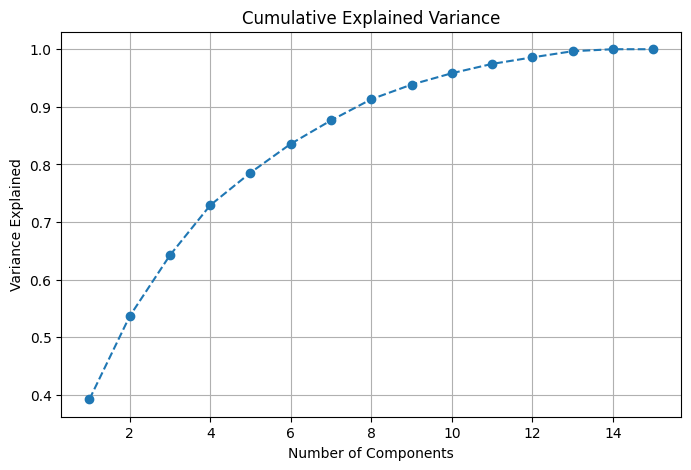

In [14]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid()
plt.show()

In [15]:
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95}")

Components needed for 95% variance: 10


In [16]:
var_2 = cumulative_variance[1]
print(f"Variance explained by first 2 components: {var_2:.2%}")

Variance explained by first 2 components: 53.68%


## 4. Inspect the components
1. Print the first principle component. What does it represent? What is special about the PC1 compared to the other components?
2. Which are the most important features of the first component, PC1?
4. What are the mutual scalar products (dot products) of the 5 most important components? What does that tell you about the components and their relationship to each other?

In [17]:
print("PC1 Loadings:\n", pca.components_[0])

PC1 Loadings:
 [ 0.11918286  0.00625976  0.27457782  0.32295854  0.25577895  0.06404061
  0.38704902 -0.35104736  0.34062072  0.21412098  0.33626866  0.0766182
 -0.00668762  0.32356274 -0.27917915]


In [18]:
feature_importance = pd.Series(pca.components_[0], index=X.columns).abs().sort_values(ascending=False)
print("\nTop features in PC1:")
print(feature_importance.head(5))


Top features in PC1:
Horsepower (bhp)         0.387049
0-100 km/h (s)           0.351047
Top Speed (km/h)         0.340621
Original Price (DKK)     0.336269
All-Wheel Drive (AWD)    0.323563
dtype: float64


In [21]:
dot_products = np.dot(pca.components_[:5], pca.components_[:5].T)
print("\nDot product matrix of first 5 PCs:")
print(np.round(dot_products, 2))


Dot product matrix of first 5 PCs:
[[ 1.  0.  0.  0.  0.]
 [ 0.  1. -0.  0. -0.]
 [ 0. -0.  1.  0. -0.]
 [ 0.  0.  0.  1.  0.]
 [ 0. -0. -0.  0.  1.]]


## 5. Reduce the dimensions

1. Use one of the three discussed methods that you analyzed in part 3 to reduce the dimensions of `X_pca`. Why did you choose that method? What are the advantages and disadvantages of that method compared to the other two methods?

In [22]:
# Choosing the 95% variance threshold method
pca_final = PCA(n_components=0.95)
X_train_reduced = pca_final.fit_transform(X_train)
X_test_reduced = pca_final.transform(X_test)

print(f"Reduced feature count: {X_train_reduced.shape[1]}")

Reduced feature count: 10


## 6. Evaluation

1. Using your best-performing algorithm from assignment 1, create a model for the reduced data set.
2. Compare the performance of the model to the performance of assignment 1. Remember to transform the test set as well. What do you notice about the performance of the model? Is it better or worse than the model from assignment 1? Why do you think that is?

In [ ]:
# I will leave this up to you to compare with your own assignment 1 :)

# B. More manual PCA

Both exercises below were borrowed from the book "Linear Algebra and Its Applications" by David C. Lay, Steven R. Lay, and Judi J. McDonald, sixth edition. They correspond to exercises 1, 3, 4, and 5 from section 7.5.

## 1. Mean-deviation form and sample covariance matrix

1. Convert the matrix of observations to mean-deviation form.
2. Verify that the mean of each column is now zero.
3. Construct the sample covariance matrix.
4. Verify that the covariance matrix is symmetric. What does that tell you about the relationship between the features? Where can you find the variances and covariances? What do the variances and covariances represent in terms of the data?

In [33]:
X1 = Matrix([19, 12])
X2 = Matrix([22, 6])
X3 = Matrix([6, 9])
X4 = Matrix([3, 15])
X5 = Matrix([2, 13])
X6 = Matrix([20, 5])

X = Matrix.hstack(X1, X2, X3, X4, X5, X6)
X

Matrix([
[19, 22, 6,  3,  2, 20],
[12,  6, 9, 15, 13,  5]])

In [34]:
# sample mean
N = 6
M = (1/N)*(X1 + X2 + X3 + X4 + X5 + X6)
M

Matrix([
[12.0],
[10.0]])

In [35]:
X1_bar = X1 - M
X2_bar = X2 - M
X3_bar = X3 - M
X4_bar = X4 - M
X5_bar = X5 - M
X6_bar = X6 - M

In [36]:
B = Matrix.hstack(X1_bar, X2_bar, X3_bar, X4_bar, X5_bar, X6_bar)
B

Matrix([
[7.0, 10.0, -6.0, -9.0, -10.0,  8.0],
[2.0, -4.0, -1.0,  5.0,   3.0, -5.0]])

In [37]:
for i in range(B.shape[0]):
    sum = 0
    for j in range(B.shape[1]):
        sum += B[i, j]
    print(f"Mean of column {i}: {sum/B.shape[1]}")

Mean of column 0: 0
Mean of column 1: 0


In [38]:
S = (1/(N-1)) * (B * B.T)
S

Matrix([
[ 86.0, -27.0],
[-27.0,  16.0]])

## 2. Manual PCA

A Landsat image with three spectral components was made of Homestead Air Force Base in Florida (after the base was hit by Hurricane Andrew in 1992). The covariance matrix of the data is shown below.

1. Find the eigenvalues and eigenvectors of $S$.
2. Construct matrices $P$ and $D$.
3. Check that $S = PDP^{T}$.
4. Find the principal components of the data. What do the principal components represent in terms of the original features? How do they relate to the eigenvectors and eigenvalues?
5. Find the first principle component and compute the percentage of the total variance that is contained in this PC using the trace.
6. Would it be enough to keep only the first PC? Why or why not? What would be the advantages and disadvantages of keeping only the first PC compared to keeping more PCs?

In [46]:
S = Matrix([[164.12, 32.73, 81.04], [32.73, 539.44, 249.13], [81.04, 249.13, 189.11]])
S

⎡164.12  32.73   81.04 ⎤
⎢                      ⎥
⎢32.73   539.44  249.13⎥
⎢                      ⎥
⎣81.04   249.13  189.11⎦

In [47]:
eigenvectors = S.eigenvects()
eigenvectors

⎡⎛                     ⎡⎡-0.12955366064964 ⎤⎤⎞  ⎛                     ⎡⎡-0.899 ↪
⎢⎜                     ⎢⎢                  ⎥⎥⎟  ⎜                     ⎢⎢       ↪
⎢⎜677.497124369087, 1, ⎢⎢-0.874422948526397⎥⎥⎟, ⎜181.581120624357, 1, ⎢⎢0.3021 ↪
⎢⎜                     ⎢⎢                  ⎥⎥⎟  ⎜                     ⎢⎢       ↪
⎣⎝                     ⎣⎣-0.46754716992265 ⎦⎦⎠  ⎝                     ⎣⎣-0.315 ↪

↪ 43466885524 ⎤⎤⎞  ⎛                     ⎡⎡-0.417412416530154⎤⎤⎞⎤
↪             ⎥⎥⎟  ⎜                     ⎢⎢                  ⎥⎥⎟⎥
↪ 23054175577 ⎥⎥⎟, ⎜33.5917550065558, 1, ⎢⎢-0.379613181048845⎥⎥⎟⎥
↪             ⎥⎥⎟  ⎜                     ⎢⎢                  ⎥⎥⎟⎥
↪ 814718778094⎦⎦⎠  ⎝                     ⎣⎣0.825627462782358 ⎦⎦⎠⎦

In [48]:
l1 = eigenvectors[0][0]
l2 = eigenvectors[1][0]
l3 = eigenvectors[2][0]
l1, l2, l3

In [49]:
v1 = eigenvectors[0][2][0]
v2 = eigenvectors[1][2][0]
v3 = eigenvectors[2][2][0]
v1, v2, v3

⎛⎡-0.12955366064964 ⎤  ⎡-0.89943466885524 ⎤  ⎡-0.417412416530154⎤⎞
⎜⎢                  ⎥  ⎢                  ⎥  ⎢                  ⎥⎟
⎜⎢-0.874422948526397⎥, ⎢0.302123054175577 ⎥, ⎢-0.379613181048845⎥⎟
⎜⎢                  ⎥  ⎢                  ⎥  ⎢                  ⎥⎟
⎝⎣-0.46754716992265 ⎦  ⎣-0.315814718778094⎦  ⎣0.825627462782358 ⎦⎠

In [51]:
l1 = l1.round(2)
l2 = l2.round(2)
l3 = l3.round(2)

D = Matrix([[l1, 0, 0], [0, l2, 0], [0, 0, l3]])
D

⎡677.5    0       0  ⎤
⎢                    ⎥
⎢  0    181.58    0  ⎥
⎢                    ⎥
⎣  0      0     33.59⎦

In [52]:
P = Matrix.hstack(v1, v2, v3)
P

⎡-0.12955366064964   -0.89943466885524   -0.417412416530154⎤
⎢                                                          ⎥
⎢-0.874422948526397  0.302123054175577   -0.379613181048845⎥
⎢                                                          ⎥
⎣-0.46754716992265   -0.315814718778094  0.825627462782358 ⎦

In [53]:
P*D*P.inv(), S

⎛⎡164.118871896851  32.7303062050448  81.0405367280609⎤  ⎡164.12  32.73   81.0 ↪
⎜⎢                                                    ⎥  ⎢                     ↪
⎜⎢32.7303062050448  539.441828170481  249.131874149844⎥, ⎢32.73   539.44  249. ↪
⎜⎢                                                    ⎥  ⎢                     ↪
⎝⎣81.0405367280609  249.131874149844  189.109221807669⎦  ⎣81.04   249.13  189. ↪

↪ 4 ⎤⎞
↪   ⎥⎟
↪ 13⎥⎟
↪   ⎥⎟
↪ 11⎦⎠

In [55]:
x1, x2, x3 = symbols('x1 x2 x3')
# approximate v1, v2, v3
v1 = v1.evalf(2)
v2 = v2.evalf(2)
v3 = v3.evalf(2)

PC1 = v1[0]*x1 + v1[1]*x2 + v1[2]*x3
PC2 = v2[0]*x1 + v2[1]*x2 + v2[2]*x3
PC3 = v3[0]*x1 + v3[1]*x2 + v3[2]*x3
PC1, PC2, PC3

In [58]:
# PC1 explained variance
trace = l1 + l2 + l3
explained1 = ((l1 / trace)*100).round(1)
explained1